# Titanic 15: AgeBand
이번 가설: 두 그룹 어린이 구분보다 여러 연령대로 나누면 나이의 비선형 관계를 표현할 수 있다.
이전까지 채택된 추가 피처: ['GenderClass', 'GenderIsChild', 'ClassIsChild'].
이번 변경: **AgeBand 하나 추가**, 다른 모델·하이퍼파라미터 변경 없음. HasCabin/AgeMissing 제외 유지.

채택 규칙(평가 전 고정): 이전 Best보다 holdout AUC 상승 → 동일 5-fold 비교 → CV 평균 상승 및 Gap 증가 0.01 이내, CV 표준편차 증가 0.005 이내이면 채택. Gap 0.01과 CV 표준편차 0.005는 운영 기준이며 통계적 유의성 기준이 아니다.
CV도 이 데이터로 후보를 고르는 보조 검증이므로 반복 선택의 낙관성이 남는다. 여러 CV fold 결과로 새 threshold를 탐색하지 않는다.
CSV는 해당 버전에서 **실제로 실험한 후보 피처 집합**의 예측을 보존한다. 탈락 피처는 다음 버전의 입력에 누적하지 않는다. 최종 채택 Best와 실험 CSV를 구분한다.

# 1. 데이터 불러오기

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
from IPython.display import display
from common.utils import train_test_split_by_target
from common.interaction_experiments import FeaturePreprocessor, fit_cat, scores, cv_compare, baseline_parameters

train = pd.read_csv('csv/train.csv')
test = pd.read_csv('csv/test.csv')
submission = pd.read_csv('csv/submission.csv')
previous_features = ['GenderClass', 'GenderIsChild', 'ClassIsChild']
new_feature = 'AgeBand'
candidate_features = previous_features + [new_feature]
previous_cv = {'mean': 0.9062327921252408, 'std': 0.018564264845361396}
print(train.shape, test.shape)
display(train.head())
display(test.head())

(916, 12) (393, 11)


,passengerid,survived,pclass,name,gender,age,sibsp,parch,ticket,fare,cabin,embarked
0,0,0,2,"Wheeler, Mr. Edwin Frederick""""",male,NaN,0,0,SC/PARIS 2159,12.8750,NaN,S
1,1,0,3,"Henry, Miss. Delia",female,NaN,0,0,382649,7.7500,NaN,Q
2,2,1,1,"Hays, Mrs. Charles Melville (Clara Jennings Gr...",female,52.0,1,1,12749,93.5000,B69,S
3,3,1,3,"Andersson, Mr. August Edvard (""Wennerstrom"")",male,27.0,0,0,350043,7.7958,NaN,S
4,4,0,2,"Hold, Mr. Stephen",male,44.0,1,0,26707,26.0000,NaN,S


,passengerid,pclass,name,gender,age,sibsp,parch,ticket,fare,cabin,embarked
0,916,3,"McGowan, Miss. Anna ""Annie""",female,15.0,0,0,330923,8.0292,NaN,Q
1,917,2,"Pinsky, Mrs. (Rosa)",female,32.0,0,0,234604,13.0000,NaN,S
2,918,3,"McCarthy, Miss. Catherine Katie""""",female,NaN,0,0,383123,7.7500,NaN,Q
3,919,3,"Franklin, Mr. Charles (Charles Fardon)",male,NaN,0,0,SOTON/O.Q. 3101314,7.2500,NaN,S
4,920,1,"Wick, Mrs. George Dennick (Mary Hitchcock)",female,45.0,1,1,36928,164.8667,NaN,S


# 2. 데이터 메타 정보 확인

In [2]:
train.info()
print(train.isna().sum())
print(train.nunique())
test.info()
print(test.isna().sum())
print('train에만:', set(train.columns)-set(test.columns))

<class 'pandas.DataFrame'>
RangeIndex: 916 entries, 0 to 915
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   passengerid  916 non-null    int64  
 1   survived     916 non-null    int64  
 2   pclass       916 non-null    int64  
 3   name         916 non-null    str    
 4   gender       916 non-null    str    
 5   age          736 non-null    float64
 6   sibsp        916 non-null    int64  
 7   parch        916 non-null    int64  
 8   ticket       916 non-null    str    
 9   fare         916 non-null    float64
 10  cabin        198 non-null    str    
 11  embarked     915 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 86.0 KB
passengerid      0
survived         0
pclass           0
name             0
gender           0
age            180
sibsp            0
parch            0
ticket           0
fare             0
cabin          718
embarked         1
dtype: int64
passengerid    916

# 3. Target 정의

In [3]:
assert set(train.columns)-set(test.columns) == {'survived'}
assert set(test.columns)-set(train.columns) == set()
target_col = 'survived'
id_col = 'passengerid'
X = train.drop(columns=[target_col, id_col])
y = train[target_col]
X_test_raw = test.drop(columns=id_col)
assert X.columns.equals(X_test_raw.columns)
assert train[id_col].is_unique and test[id_col].is_unique
assert set(train[id_col]).isdisjoint(test[id_col])

# 4. Target 분석
Baseline과 같은 seed 42, stratify, validation 25%를 유지합니다.

In [4]:
print(y.value_counts(normalize=True))
train_part, valid_part = train_test_split_by_target(train, target_name=target_col)
X_tr_raw = train_part.drop(columns=[target_col, id_col])
y_tr = train_part[target_col]
X_valid_raw = valid_part.drop(columns=[target_col, id_col])
y_valid = valid_part[target_col]
assert len(train_part)==687 and len(valid_part)==229
print('학습/검증:', X_tr_raw.shape, X_valid_raw.shape)

survived
0    0.622271
1    0.377729
Name: proportion, dtype: float64
학습/검증: (687, 10) (229, 10)


# 5. EDA
학습 부분만 사용해 후보를 임시 계산하고 target과의 관계를 확인합니다. 모델 입력에 채택하기 전의 점검입니다.
생성 방법 / 사용 원본: 학습 그룹 중앙값으로 치환한 age를 [0,16), [16,20), [20,35), [35,60), [60,inf)로 구분. Child/Teen/YoungAdult/Adult/Senior. 관측 연령의 학습 표본은 각 62/67/257/152/23명으로 모든 구간에 관측이 있다. 성능을 보고 경계를 변경하지 않는다.
validation/test는 빈도·구간·중앙값 결정에 사용하지 않습니다.

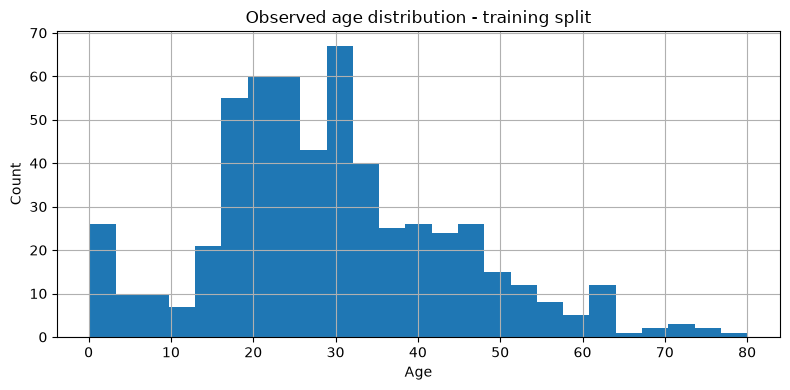

Age missing: 126


,count,mean
AgeBand,,
Adult,173,0.375723
Child,62,0.516129
Senior,23,0.347826
Teen,67,0.388060
YoungAdult,362,0.356354


EDA 표본 수: 687


In [5]:
eda_prep = FeaturePreprocessor(candidate_features).fit_missing(X_tr_raw)
eda_frame = eda_prep.feature_frame(X_tr_raw, eda_prep.transform_missing(X_tr_raw))
eda_frame[target_col] = y_tr
import matplotlib.pyplot as plt
plt.figure(figsize=(8,4))
X_tr_raw['age'].hist(bins=25)
plt.title('Observed age distribution - training split')
plt.xlabel('Age')
plt.ylabel('Count')
plt.tight_layout()
plt.show()
print('Age missing:', X_tr_raw['age'].isna().sum())
display(eda_frame.groupby(new_feature,dropna=False)[target_col].agg(['count','mean']))
print('EDA 표본 수:', len(eda_frame))

해석 기준: age의 결정적 구간화로 원천 정보는 같다. 어린이 조합 피처와 부분 중복되며, 표본이 적은 Senior의 비율은 불안정할 수 있다. 숫자형의 Pearson 상관만으로 삭제하지 않습니다. 카테고리 표의 count가 작을수록 평균 생존율을 조심해서 해석합니다.

# 6. 데이터 전처리
## 6-1. 결측치
Baseline의 나이 그룹 중앙값, 전체 중앙값 fallback, 수치형 중앙값/범주형 최빈값과 cabin 원문 삭제를 재사용합니다. 원본 X는 보존하여 이름/티켓/객실 파생변수에 사용합니다.

In [6]:
prep = FeaturePreprocessor(candidate_features).fit_missing(X_tr_raw)
X_tr_clean = prep.transform_missing(X_tr_raw)
X_valid_clean = prep.transform_missing(X_valid_raw)
assert not X_tr_clean.isna().any().any()
assert not X_valid_clean.isna().any().any()

## 6-2. Feature 생성
Baseline FamilySize/IsAlone + 이전 채택 피처 + 이번 AgeBand만 생성합니다. 실제 생성 함수는 새 common/feature_experiments.py에 있고 기존 common은 그대로입니다.

In [7]:
X_tr_features = prep.feature_frame(X_tr_raw, X_tr_clean)
X_valid_features = prep.feature_frame(X_valid_raw, X_valid_clean)
print('추가 피처:', candidate_features)
print('인코딩 전:', X_tr_features.columns.tolist())
display(X_tr_features.head())

추가 피처: ['GenderClass', 'GenderIsChild', 'ClassIsChild', 'AgeBand']
인코딩 전: ['pclass', 'gender', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'FamilySize', 'IsAlone', 'GenderClass', 'GenderIsChild', 'ClassIsChild', 'AgeBand']


,pclass,gender,age,sibsp,parch,fare,embarked,FamilySize,IsAlone,GenderClass,GenderIsChild,ClassIsChild,AgeBand
595,3,male,0.83,0,1,9.3500,S,2,0,male_3,male_1,3_1,Child
148,3,male,24.00,0,0,8.0500,S,1,1,male_3,male_0,3_0,YoungAdult
347,3,female,9.00,1,1,15.2458,C,3,0,female_3,female_1,3_1,Child
731,3,female,24.00,0,2,16.7000,S,3,0,female_3,female_0,3_0,YoungAdult
457,2,male,44.00,0,0,13.0000,S,1,1,male_2,male_0,2_0,Adult


## 6-3. 중복/Feature 관계 확인
이름/티켓 원문은 baseline처럼 제외합니다. 파생 정보가 있으면 그 피처만 남습니다. Row 중복은 baseline처럼 검증만 하며 승객을 제거하지 않습니다.

In [8]:
assert train.duplicated().sum()==0
assert train.drop(columns=id_col).duplicated().sum()==0
if pd.api.types.is_numeric_dtype(X_tr_features[new_feature]):
    numeric = X_tr_features.select_dtypes(include='number')
    display(numeric.corr()[new_feature].sort_values())
else:
    display(pd.crosstab(X_tr_features[new_feature], X_tr_features['GenderClass']))
    display(pd.crosstab(X_tr_features[new_feature], X_tr_raw['pclass']))
    display(pd.crosstab(X_tr_features[new_feature], X_tr_raw['gender']))

GenderClass,female_1,female_2,female_3,male_1,male_2,male_3
AgeBand,,,,,,
Adult,34,11,12,62,24,30
Child,1,6,22,3,6,24
Senior,4,1,1,10,5,2
Teen,6,7,15,2,11,26
YoungAdult,21,34,65,22,54,166


pclass,1,2,3
AgeBand,,,
Adult,96,35,42
Child,4,12,46
Senior,14,6,3
Teen,8,18,41
YoungAdult,43,88,231


gender,female,male
AgeBand,,
Adult,57,116
Child,29,33
Senior,6,17
Teen,28,39
YoungAdult,120,242


age의 결정적 구간화로 원천 정보는 같다. 어린이 조합 피처와 부분 중복되며, 표본이 적은 Senior의 비율은 불안정할 수 있다.

## 6-4. Encoding
학습 부분에서만 OneHotEncoder를 fit하고 validation에는 transform만 합니다. 새로운 범주형도 같은 방식, 미관측 범주는 ignore입니다.

In [9]:
prep.fit_encoding(X_tr_features)
X_tr_model = prep.transform_encoding(X_tr_features)
X_valid_model = prep.transform_encoding(X_valid_features)
assert X_tr_model.columns.equals(X_valid_model.columns)
assert X_tr_model.index.equals(y_tr.index)
print(X_tr_model.shape, X_valid_model.shape)

(687, 33) (229, 33)


## 6-5. Scaling
Baseline과 동일하게 적용하지 않습니다.

In [10]:
assert np.isfinite(X_tr_model.to_numpy()).all()
assert np.isfinite(X_valid_model.to_numpy()).all()

# 7. 모델 학습
원본 baseline, 이전 Best, 후보를 동일한 모델로 학습합니다. 원본 baseline의 실제 파라미터 전체와 후보를 비교합니다. learning_rate 등의 자동 기본값도 같은 학습 크기에서 동일해야 합니다.

In [11]:
reference_prep = FeaturePreprocessor()
reference_X = reference_prep.fit_transform(X_tr_raw)
reference_valid = reference_prep.transform(X_valid_raw)
reference_model = fit_cat(reference_X, y_tr)
reference_scores = scores(reference_model, reference_X, y_tr, reference_valid, y_valid)
assert abs(reference_scores['validation_auc'] - 0.900065) < 0.000001
previous_prep = FeaturePreprocessor(previous_features)
previous_X = previous_prep.fit_transform(X_tr_raw)
previous_valid = previous_prep.transform(X_valid_raw)
previous_model = reference_model if not previous_features else fit_cat(previous_X, y_tr)
previous_scores = scores(previous_model, previous_X, y_tr, previous_valid, y_valid)
assert len(previous_features) != 1 or abs(previous_scores['validation_auc'] - 0.902911) < 0.000001
candidate_model = fit_cat(X_tr_model, y_tr)
assert candidate_model.get_all_params() == reference_model.get_all_params()
assert previous_model.get_all_params() == reference_model.get_all_params()
print('명시적 설정:', baseline_parameters())
print('실효 설정:', candidate_model.get_all_params())

명시적 설정: {'verbose': 0, 'random_state': 42, 'cat_features': [], 'allow_writing_files': False}
실효 설정: {'nan_mode': 'Min', 'eval_metric': 'Logloss', 'iterations': 1000, 'sampling_frequency': 'PerTree', 'leaf_estimation_method': 'Newton', 'random_score_type': 'NormalWithModelSizeDecrease', 'grow_policy': 'SymmetricTree', 'penalties_coefficient': 1, 'boosting_type': 'Plain', 'model_shrink_mode': 'Constant', 'feature_border_type': 'GreedyLogSum', 'bayesian_matrix_reg': 0.10000000149011612, 'eval_fraction': 0, 'force_unit_auto_pair_weights': False, 'l2_leaf_reg': 3, 'random_strength': 1, 'rsm': 1, 'boost_from_average': False, 'model_size_reg': 0.5, 'pool_metainfo_options': {'tags': {}}, 'subsample': 0.800000011920929, 'use_best_model': False, 'class_names': [0, 1], 'random_seed': 42, 'depth': 6, 'posterior_sampling': False, 'border_count': 254, 'classes_count': 0, 'auto_class_weights': 'None', 'sparse_features_conflict_fraction': 0, 'leaf_estimation_backtracking': 'AnyImprovement', 'best_mode

# 8. Evaluation
양성 클래스 확률로 AUC를 계산합니다. 이전 Best 대비 상승 후보만 5-fold를 수행합니다.

In [12]:
candidate_scores = scores(candidate_model, X_tr_model, y_tr, X_valid_model, y_valid)
holdout_delta = candidate_scores['validation_auc'] - previous_scores['validation_auc']
original_delta = candidate_scores['validation_auc'] - reference_scores['validation_auc']
display(pd.DataFrame({'Original baseline':reference_scores, 'Previous best':previous_scores, 'Candidate':candidate_scores}))
print('이전 Best 대비:', holdout_delta, '최초 baseline 대비:', original_delta)
candidate_cv = None
cv_folds = None
if holdout_delta > 0:
    cv_folds, cv_table = cv_compare(X, y, previous_features, candidate_features)
    display(cv_folds.pivot(index='fold', columns='model', values='auc'))
    display(cv_table)
    previous_cv = cv_table.loc['Previous best'].to_dict()
    candidate_cv = cv_table.loc['Candidate'].to_dict()
accepted = (holdout_delta > 0 and candidate_cv is not None
            and candidate_cv['mean'] >= previous_cv['mean']
            and candidate_cv['std'] <= previous_cv['std'] + 0.005
            and candidate_scores['gap'] <= previous_scores['gap'] + 0.01)
best_features = candidate_features if accepted else previous_features
best_scores = candidate_scores if accepted else previous_scores
best_cv = candidate_cv if accepted else previous_cv
print('채택:', accepted, '다음 버전의 Best:', best_features)

,Original baseline,Previous best,Candidate
train_auc,0.963079,0.964795,0.965299
validation_auc,0.900065,0.906489,0.903643
gap,0.063014,0.058306,0.061656


이전 Best 대비: -0.002845991218084154 최초 baseline 대비: 0.003577817531305927
채택: False 다음 버전의 Best: ['GenderClass', 'GenderIsChild', 'ClassIsChild']


# 9. 전체 Train 재학습
요청한 버전별 CSV는 채택 여부와 무관하게 이번에 실험한 후보 피처로 생성합니다. 다음 실험은 채택된 Best만 이어받습니다. 전체 train 학습도 같은 크기의 원본 baseline과 실효 파라미터를 대조합니다.

In [13]:
full_reference_prep = FeaturePreprocessor()
full_reference_X = full_reference_prep.fit_transform(X)
full_reference_model = fit_cat(full_reference_X, y)
final_prep = FeaturePreprocessor(candidate_features)
X_full_model = final_prep.fit_transform(X)
submission_model = fit_cat(X_full_model, y)
assert submission_model.get_all_params() == full_reference_model.get_all_params()
print('이 버전 CSV의 피처:', X_full_model.columns.tolist())
print('최종 학습 실효 파라미터:', submission_model.get_all_params())

이 버전 CSV의 피처: ['pclass', 'age', 'sibsp', 'parch', 'fare', 'FamilySize', 'IsAlone', 'gender_female', 'gender_male', 'embarked_C', 'embarked_Q', 'embarked_S', 'GenderClass_female_1', 'GenderClass_female_2', 'GenderClass_female_3', 'GenderClass_male_1', 'GenderClass_male_2', 'GenderClass_male_3', 'GenderIsChild_female_0', 'GenderIsChild_female_1', 'GenderIsChild_male_0', 'GenderIsChild_male_1', 'ClassIsChild_1_0', 'ClassIsChild_1_1', 'ClassIsChild_2_0', 'ClassIsChild_2_1', 'ClassIsChild_3_0', 'ClassIsChild_3_1', 'AgeBand_Adult', 'AgeBand_Child', 'AgeBand_Senior', 'AgeBand_Teen', 'AgeBand_YoungAdult']
최종 학습 실효 파라미터: {'nan_mode': 'Min', 'eval_metric': 'Logloss', 'iterations': 1000, 'sampling_frequency': 'PerTree', 'leaf_estimation_method': 'Newton', 'random_score_type': 'NormalWithModelSizeDecrease', 'grow_policy': 'SymmetricTree', 'penalties_coefficient': 1, 'boosting_type': 'Plain', 'model_shrink_mode': 'Constant', 'feature_border_type': 'GreedyLogSum', 'bayesian_matrix_reg': 0.1000000014

# 10. Test 예측

In [14]:
X_test_model = final_prep.transform(X_test_raw)
assert X_test_model.columns.equals(X_full_model.columns)
positive_index = list(submission_model.classes_).index(1)
predictions = submission_model.predict_proba(X_test_model)[:, positive_index]
assert np.isfinite(predictions).all()
assert ((predictions>=0)&(predictions<=1)).all()

# 11. Submission 생성
템플릿 예측 열만 교체하고 원래 ID/순서를 유지합니다. 기존 버전 덮어쓰기를 방지합니다.

In [15]:
output_path = Path('submission/titanic_result_15.csv')
assert not output_path.exists(), '기존 결과를 덮어쓰지 않습니다.'
assert submission.columns.tolist()==[id_col,target_col]
assert len(submission)==len(test)
assert submission[id_col].is_unique and submission[id_col].notna().all()
assert set(submission[id_col])==set(test[id_col])
result = submission.copy(deep=True)
by_id = pd.Series(predictions,index=test[id_col].to_numpy())
result[target_col] = result[id_col].map(by_id)
assert result[target_col].notna().all()
result.to_csv(output_path,index=False)
saved = pd.read_csv(output_path)
assert saved.shape==submission.shape==(len(test),2)
assert saved.columns.equals(submission.columns)
pd.testing.assert_frame_equal(saved.drop(columns=target_col),submission.drop(columns=target_col))
assert pd.api.types.is_float_dtype(saved[target_col])
assert saved[target_col].notna().all() and saved[target_col].between(0,1).all()
np.testing.assert_allclose(saved[target_col],by_id.loc[submission[id_col]],atol=1e-15,rtol=1e-12)
print('검증 통과:', output_path, saved.shape)

AssertionError: 기존 결과를 덮어쓰지 않습니다.

## 최종 누적 Best 모델
아래 모델은 채택된 피처만 포함합니다. 위 15차 실험 CSV는 CabinDeck 후보의 기록이며 이 변수와 구분합니다.

In [20]:
best_final_prep = FeaturePreprocessor(best_features)
best_final_X = best_final_prep.fit_transform(X)
best_final_model = fit_cat(best_final_X, y)
assert best_final_model.get_all_params()==full_reference_model.get_all_params()
print('최종 누적 Best feature:', best_final_X.columns.tolist())

최종 누적 Best feature: ['pclass', 'age', 'sibsp', 'parch', 'fare', 'FamilySize', 'IsAlone', 'gender_female', 'gender_male', 'embarked_C', 'embarked_Q', 'embarked_S', 'GenderClass_female_1', 'GenderClass_female_2', 'GenderClass_female_3', 'GenderClass_male_1', 'GenderClass_male_2', 'GenderClass_male_3', 'GenderIsChild_female_0', 'GenderIsChild_female_1', 'GenderIsChild_male_0', 'GenderIsChild_male_1', 'ClassIsChild_1_0', 'ClassIsChild_1_1', 'ClassIsChild_2_0', 'ClassIsChild_2_1', 'ClassIsChild_3_0', 'ClassIsChild_3_1']


In [18]:
import shap
import skimage

c:\dev\study\machine_learning\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [23]:
explainer = shap.TreeExplainer(best_final_model)
shap_values = explainer.shap_values(X_test_model)

In [24]:
shap_values[1].shape , X_test_model.shape

((33,), (393, 33))

C:\Users\Playdata\AppData\Local\Temp\ipykernel_29532\3384964745.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test_model)


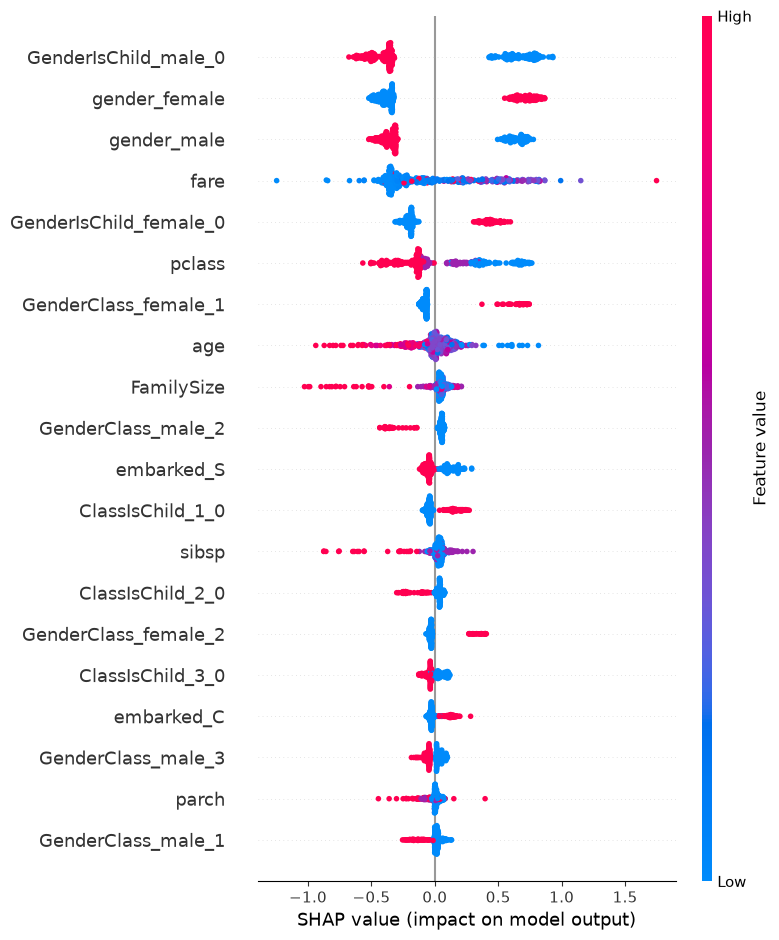

In [26]:
shap.summary_plot(shap_values, X_test_model)

## 실제 EDA 결과와 중복성 해석
치환 후 Child 62명/51.6%, Teen 67명/38.8%, YoungAdult 362명/35.6%, Adult 173명/37.6%, Senior 23명/34.8%다. 원본 나이 관측 히스토그램을 함께 확인했다. age 구간화는 결정적 재표현이며 Child 경계는 기존 어린이 interaction과 중복된다. 추가한 여러 구간은 이번 holdout 개선으로 연결되지 않았다.

# 12. 해당 버전 실험 결과

가설: 두 그룹 어린이 구분보다 여러 연령대로 나누면 나이의 비선형 관계를 표현할 수 있다.

| 항목 | 이전 Best | 이번 실험 |
|---|---:|---:|
| train_auc | 0.964795 | 0.965299 |
| validation_auc | 0.906489 | 0.903643 |
| gap | 0.058306 | 0.061656 |
| CV mean | 0.906233 | 미실행 |
| CV std | 0.018564 | 미실행 |

**제외**: holdout 개선 없음. 이전 Best 대비 -0.002846, 최초 baseline 대비 +0.003578.

다음 버전의 추가 피처: ['GenderClass', 'GenderIsChild', 'ClassIsChild'].
이번 CSV 입력: ['GenderClass', 'GenderIsChild', 'ClassIsChild', 'AgeBand'].

기존 피처와의 관계: age의 결정적 구간화로 원천 정보는 같다. 어린이 조합 피처와 부분 중복되며, 표본이 적은 Senior의 비율은 불안정할 수 있다.
개별 집단 비율은 EDA 표에 있으며 소표본/인과관계 해석에 주의합니다. CV 미실행은 0점이 아니라 holdout에서 우선 제외했음을 의미합니다.


## 3~15 전체 결과

| 버전 | Feature | Train AUC | Validation AUC | Gap | CV Mean | CV Std | 이전 Best 대비 | 판단 |
|---|---|---:|---:|---:|---:|---:|---:|---|
| Base | Baseline | 0.963079 | 0.900065 | 0.063014 | 0.901775 | 0.016322 | — | 기준 |
| 3 | Title | 0.965168 | 0.902992 | 0.062176 | 0.900010 | 0.016136 | +0.002927 | 제외 |
| 4 | GenderClass | 0.963047 | 0.902911 | 0.060136 | 0.904676 | 0.016132 | +0.002846 | 채택 |
| 5 | FamilyGroup | 0.964434 | 0.902748 | 0.061686 | 미실행 | 미실행 | -0.000163 | 제외 |
| 6 | TicketGroupSize | 0.964691 | 0.899984 | 0.064707 | 미실행 | 미실행 | -0.002927 | 제외 |
| 7 | FarePerPerson | 0.965835 | 0.902748 | 0.063087 | 미실행 | 미실행 | -0.000163 | 제외 |
| 8 | IsChild | 0.964218 | 0.903155 | 0.061063 | 0.902251 | 0.017383 | +0.000244 | 제외 |
| 9 | CabinDeck | 0.964011 | 0.904781 | 0.059230 | 0.902823 | 0.013704 | +0.001870 | 제외 |
| 10 | GenderIsChild | 0.965065 | 0.904293 | 0.060771 | 0.905907 | 0.017324 | +0.001382 | 채택 |
| 11 | ClassIsChild | 0.964795 | 0.906489 | 0.058306 | 0.906233 | 0.018564 | +0.002195 | 채택 |
| 12 | GenderIsAlone | 0.963471 | 0.904619 | 0.058852 | 미실행 | 미실행 | -0.001870 | 제외 |
| 13 | EmbarkedClass | 0.963489 | 0.905757 | 0.057732 | 미실행 | 미실행 | -0.000732 | 제외 |
| 14 | TicketPrefix | 0.969699 | 0.902423 | 0.067276 | 미실행 | 미실행 | -0.004066 | 제외 |
| 15 | AgeBand | 0.965299 | 0.903643 | 0.061656 | 미실행 | 미실행 | -0.002846 | 제외 |

## 질문별 답변
1. **GenderClass 이후 interaction 효과:** GenderIsChild, ClassIsChild가 동일 holdout과 CV 모두 개선돼 채택됐다. 다른 두 interaction은 제외됐다.
2. **성별과 결합해 약했던 피처가 살아났는가:** 단독 IsChild는 과거 CV 기준에 미달했지만 GenderIsChild는 이번에 통과했다. 모든 약한 피처가 조합으로 유용해진다는 뜻은 아니다.
3. **IsChild interaction:** GenderIsChild를 먼저 채택한 뒤 ClassIsChild를 추가하는 누적 순서에서도 개선됐다. 단독 ClassIsChild의 독립 효과를 측정한 실험은 아니다.
4. **TicketPrefix와 TicketGroupSize:** 둘 다 각 시점 Best보다 holdout이 낮아 제외됐다. 이전 실험과 이번 실험의 기준 피처 집합이 달라 절대 AUC만으로 우열을 단정하지 않는다.
5. **AgeBand와 IsChild:** AgeBand는 여러 연령대로 표현했지만 이미 어린이 interaction 2개가 있는 현재 Best를 개선하지 못했다. 서로 같은 피처 조건에서 직접 비교한 결과가 아니므로 일반적 우열은 미확정이다.
6. **Target 관계:** 성별을 포함한 그룹에서 큰 생존율 차이가 관측된다. GenderIsChild의 남성 성인 10.6% 대 여성 성인 87.2%가 대표적이다. 이는 기존 성별 정보도 반영하므로 독립적인 기여 순위로 해석하지 않는다. 희소 ClassIsChild/Prefix 그룹의 극단 비율은 신뢰하기 어렵다.
7. **중복성:** GenderIsAlone은 기존 gender/IsAlone의 정확한 조합이고 AgeBand는 age의 결정적 구간화다. 다른 interaction도 새 원천 정보는 아니다. TicketPrefix는 PC→1등급, A4/A5→3등급 등 등급과 강하게 겹친다. 범주형 상관계수 하나로 순위를 매기지 않았다.
8. **실제 개선:** GenderIsChild, ClassIsChild만 채택됐다. 이번 누적 결과의 개선이지 미래 데이터의 성능 보증은 아니다.

## 최종 Best
- 기본 12개: pclass, age, sibsp, parch, fare, FamilySize, IsAlone, gender 원핫 2열, embarked 원핫 3열.
- 기존 채택 GenderClass 원핫 6열.
- 이번 채택 GenderIsChild 원핫 4열 + ClassIsChild 원핫 6열.
- 최종 입력 **28개**.
- Train AUC **0.964795**, Validation AUC **0.906489**, Gap **0.058306**.
- CV Mean **0.906233**, CV Std(ddof=1) **0.018564**.
- 시작 Best 대비 holdout **+0.003578**, CV Mean **+0.001557**. CV 표준편차는 약 **+0.002432** 증가했다.
- 11차 후보가 최종 Best에 해당한다. 12~15차 CSV는 탈락한 후보들의 실험 기록이므로 최신 번호가 곧 Best를 의미하지 않는다.
- 탈락: GenderIsAlone, EmbarkedClass, TicketPrefix, AgeBand 모두 이전 Best 대비 holdout 개선 없음. 후보 CV는 미실행이며 CV 점수가 0이라는 뜻이 아니다.

## 검증 및 한계
같은 학습 크기의 baseline과 명시적/실효 CatBoost 파라미터 전체 일치를 assert로 확인했다. 자동 learning_rate 기본 동작도 유지했다. Hyperparameter/threshold tuning·앙상블은 하지 않았다.
중앙값/최빈값/희귀 Prefix 목록/인코더는 각각 학습 부분에서만 fit했다. 검증이나 test로 피처를 선택하거나 통계를 계산하지 않았다.
각 노트북은 독립 실행 가능하며 기존 CSV 덮어쓰기를 방지하는 검사가 있어 결과 파일이 존재하면 저장 단계에서 중단된다.
CV는 같은 데이터에서 누적 후보를 선택하는 보조 지표다. 표준편차 증가를 포함해 신중하게 해석해야 하며, 모델 간 작은 차이의 통계적 유의성은 검증하지 않았다.
